In [21]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os

In [22]:
zip_file_path = '/content/archive (21).zip'
extract_path = '/content/extracted_dataset'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

Dataset extracted to: /content/extracted_dataset


In [23]:
dataset_path = '/content/extracted_dataset/brain_tumor_dataset'

img_height = 224
img_width = 224
batch_size = 32

In [24]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 253 files belonging to 2 classes.
Using 203 files for training.


In [25]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [26]:
class_names = train_ds.class_names

print("Classes:", class_names)

Classes: ['no', 'yes']


In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

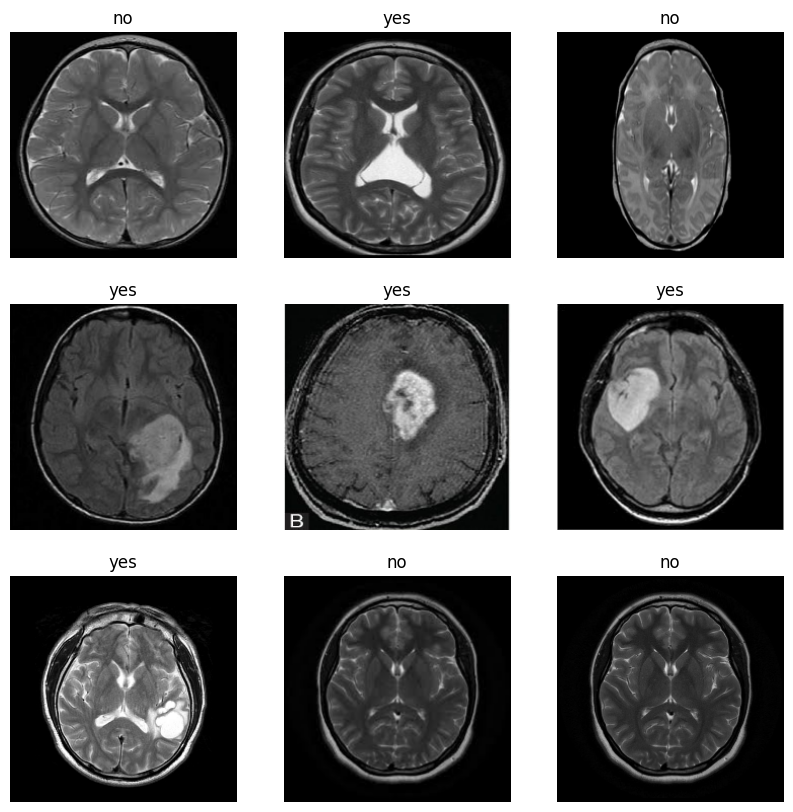

In [28]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [29]:
model = Sequential([

    Rescaling(1./255, input_shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5517 - loss: 1.0430 - val_accuracy: 0.7800 - val_loss: 0.5485
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.7635 - loss: 0.5494 - val_accuracy: 0.8000 - val_loss: 0.5276
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8276 - loss: 0.4673 - val_accuracy: 0.8000 - val_loss: 0.5444
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8227 - loss: 0.3805 - val_accuracy: 0.8400 - val_loss: 0.5534
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8621 - loss: 0.3562 - val_accuracy: 0.8600 - val_loss: 0.5356
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9064 - loss: 0.2706 - val_accuracy: 0.8800 - val_loss: 0.6030
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9113 - loss: 0.2001 - val_accuracy: 0.8800 - val_loss: 0.6198
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9212 - loss: 0.2028 - val_accuracy: 0.8800 - val_loss: 0.6315
Epoch 9/

In [33]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - accuracy: 0.8600 - loss: 0.6720
Validation Accuracy: 0.8600000143051147


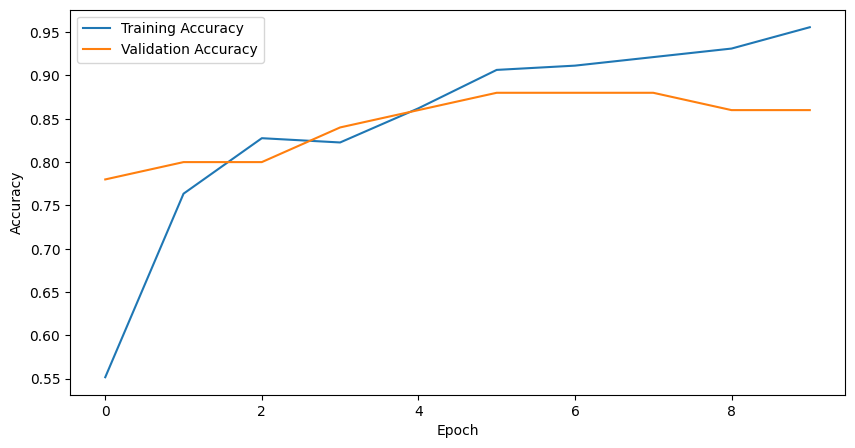

In [34]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [35]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step


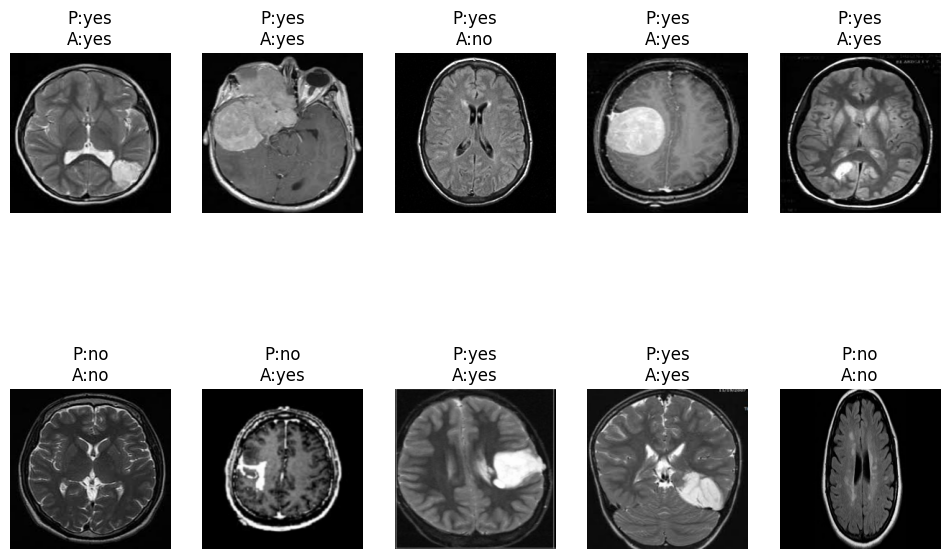

In [36]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class = class_names[np.argmax(predictions[i])]
    actual_class = class_names[labels[i]]

    plt.title(f"P:{predicted_class}\nA:{actual_class}")
    plt.axis("off")

plt.show()

Saving images.jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


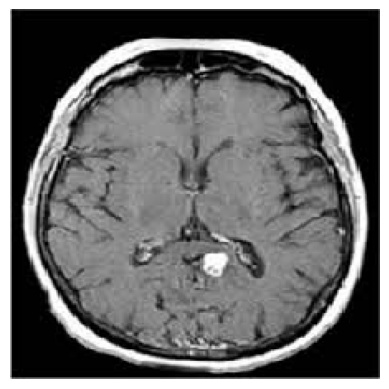

Prediction: no
Confidence: 50.27%
No Brain Tumor Detected


In [37]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Upload image
uploaded = files.upload()

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Display image
plt.imshow(img)
plt.axis('off')
plt.show()

# Print prediction
print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

if predicted_class == "yes":
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor Detected")